# Lab 6
### Morphology

Skimage morphology operators' documentation:
https://scikit-image.org/docs/dev/api/skimage.morphology.html

In [394]:
from commonfunctions import *
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.morphology import binary_erosion, binary_dilation, binary_closing,skeletonize, thin
from skimage.measure import find_contours
from skimage.draw import rectangle
from skimage.filters import threshold_otsu

# Show the figures / plots inside the notebook
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


0.5965197939644608


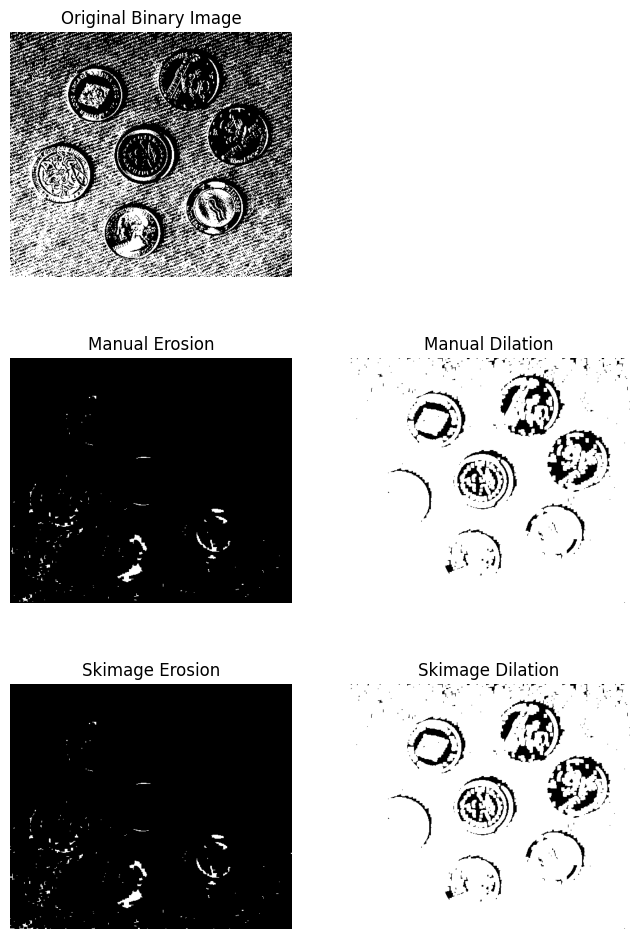

In [395]:
# def manual_dilation(img, size): 
#     pad = size // 2
#     padded = np.pad(img, pad, mode='constant', constant_values=0)
#     result = np.zeros_like(img)
#     for i in range(img.shape[0]):
#         for j in range(img.shape[1]):
#             region = padded[i:i+size, j:j+size]
#             result[i, j] = np.any(region)
#     return result

# def manual_erosion(img, size): 
#     pad = size // 2
#     padded = np.pad(img, pad, mode='constant', constant_values=0)
#     result = np.zeros_like(img)
#     for i in range(img.shape[0]):
#         for j in range(img.shape[1]):
#             region = padded[i:i+size, j:j+size]
#             result[i, j] = np.all(region)
#     return result

'''
1) Erosion / Dilation:
    - Load "coins.jpg" from the img folder
    - Convert the image to binary
    - Write 2 functions each applying 1 of the erosion/dilation algorithms (with adjustable square window size) manually to the binary image
    - Use Skimage's "binary_erosion" & "binary_dilation" & show the results
'''
img = io.imread('img/coins.jpg')
img_gray = rgb2gray(img)
thresh = threshold_otsu(img_gray)
print(thresh)
# thresh = 0.5
img_binary = img_gray > thresh
def manual_erosion(img, rows, cols):
    pad_y = rows // 2
    pad_x = cols // 2
    padded = np.pad(img, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
    result = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+rows, j:j+cols]
            result[i, j] = np.all(region)
    return result

def manual_dilation(img, rows, cols): 
    pad_y = rows // 2
    pad_x = cols // 2
    padded = np.pad(img, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
    result = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+rows, j:j+cols]
            result[i, j] = np.any(region)
    return result

size = 5
eroded_manual = manual_erosion(img_binary, size, size)
dilated_manual = manual_dilation(img_binary, size, size)
eroded_skimage = binary_erosion(img_binary, footprint=np.ones((size, size)))
dilated_skimage = binary_dilation(img_binary, footprint=np.ones((size, size)))


fig, ax = plt.subplots(3, 2, figsize=(8, 12))
ax[0, 0].imshow(img_binary, cmap='gray')
ax[0, 0].set_title('Original Binary Image')
ax[0, 0].axis('off')
ax[0, 1].axis('off')
ax[1, 0].imshow(eroded_manual, cmap='gray')
ax[1, 0].set_title('Manual Erosion')
ax[1, 0].axis('off')
ax[1, 1].imshow(dilated_manual, cmap='gray')
ax[1, 1].set_title('Manual Dilation')
ax[1, 1].axis('off')
ax[2, 0].imshow(eroded_skimage, cmap='gray')
ax[2, 0].set_title('Skimage Erosion')
ax[2, 0].axis('off')
ax[2, 1].imshow(dilated_skimage, cmap='gray')
ax[2, 1].set_title('Skimage Dilation')
ax[2, 1].axis('off')

plt.show()

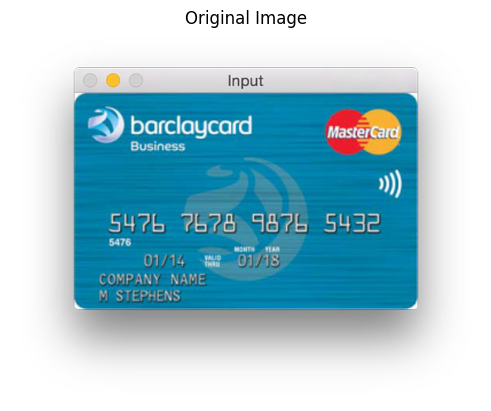

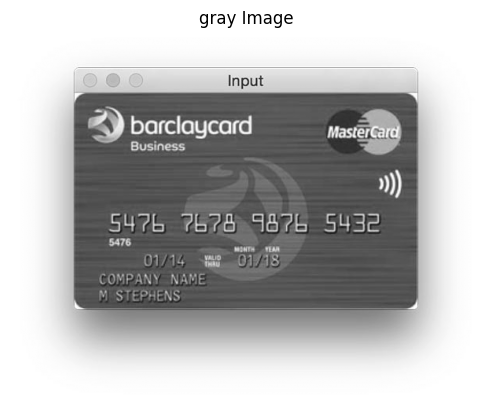

0.6815237936580881


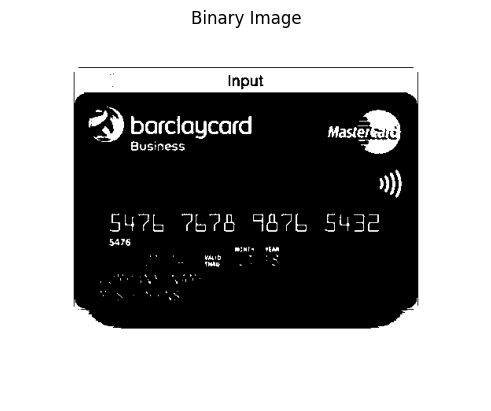

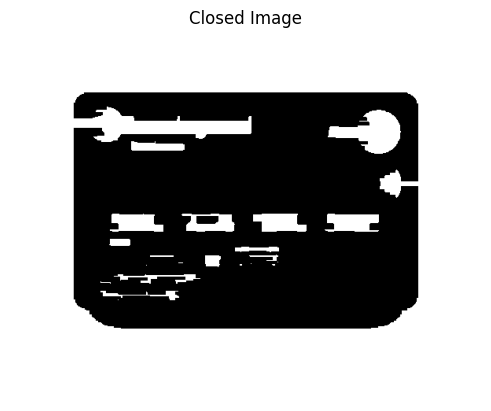

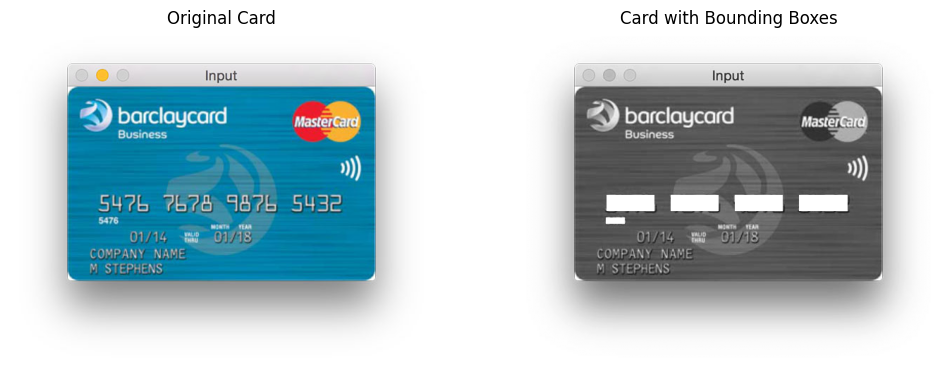

In [396]:
'''
2) Case Study: Credit Card Number Extraction
    - Load "card.jpg" from the img folder
    - Convert the image to binary by brightness thresholding maintaining the card number details for extraction
    - Use your erosion/dilation functions, or Skimage's functions only if you didn't implement them, to apply closing
        Note: The goal of this step is to join the card number into 4 sets of connected pixels
    - Use Skimage's "find_contours" to get the bounding boxes for the credit card's numbers by filtering on aspect ratio (between 2.5 & 3.5)
        Note: When using "find_contours(img, 0.8)" the o/p is a list of contours each having:
                - contour[:,0] being the Y values of the contour perimeter points
                - contour[:,1] being the X values of the contour perimeter points
'''

def show (img, title='Image'):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def manual_closing(img, rows, cols):
    dilated = manual_dilation(img, rows, cols)
    closed = manual_erosion(dilated, rows, cols)
    return closed

card_img = io.imread('img/card.jpg')
show(card_img, title='Original Image')
card_gray = rgb2gray(card_img)
show(card_gray, title='gray Image')
thresh = threshold_otsu(card_gray)
print(thresh)
#thresh = 0.7
card_binary = card_gray > thresh 
show(card_binary, title='Binary Image')


closed_img = binary_closing(card_binary, footprint=np.ones((4, 22)))

#closed_img = manual_closing(card_binary, rows=4, cols=22)
show(closed_img, title='Closed Image')

contours = find_contours(closed_img, 0.8)


bounding_boxes = []
for contour in contours:
    y = contour[:, 0]
    x = contour[:, 1]
    Xmin, Xmax = np.min(x), np.max(x)
    Ymin, Ymax = np.min(y), np.max(y)
    width = Xmax - Xmin
    height = Ymax - Ymin
    if height > 0 and 2.5 <= width / height <= 3.5:
        bounding_boxes.append([Xmin, Xmax, Ymin, Ymax])


img_with_boxes = card_gray.copy()

for box in bounding_boxes:
    [Xmin, Xmax, Ymin, Ymax] = box
    rr, cc = rectangle(start = (Ymin,Xmin), end = (Ymax,Xmax), shape=img_gray.shape)
    img_with_boxes[rr, cc] = 1

fig, ax = plt.subplots(1, 2, figsize=(12, 12))
ax[0].imshow(card_img, cmap='gray')
ax[0].set_title('Original Card')
ax[0].axis('off')
ax[1].imshow(img_with_boxes, cmap='gray')
ax[1].set_title('Card with Bounding Boxes')
ax[1].axis('off')
plt.show()

0.494140625


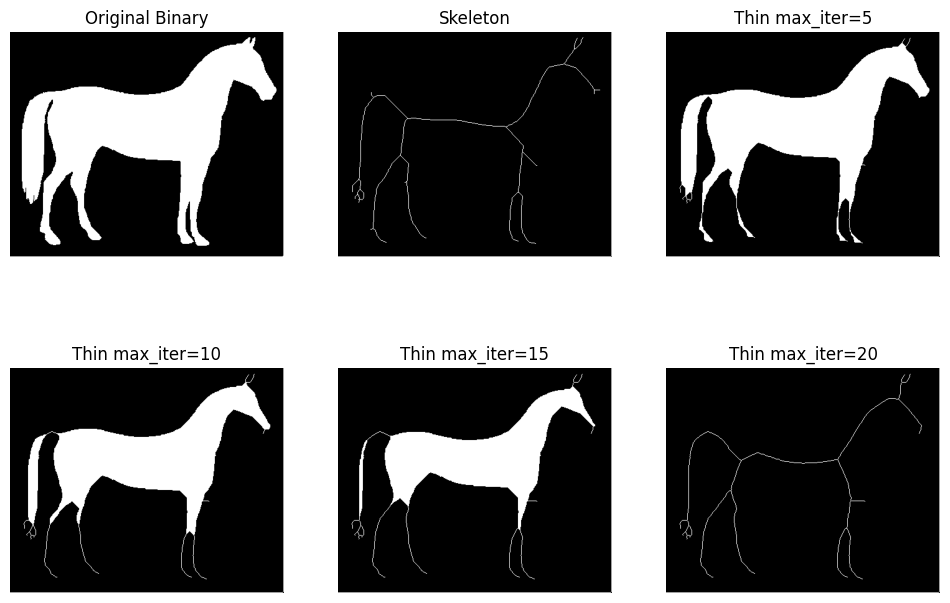

In [397]:
'''
3) Skeletonization:
    - Load "horse.jpg" from the img folder 
    - Use a binary threshold of 0.9 to remove invisible noise in the background
    - Use Skimage's "skeletonize(image)" to acquire the image's skeleton & show it
    - Use Skimage's "thin(image, max_iter)" with values of max_iter 5/10/15/20 & show it
'''

horse_img = io.imread('img/horse.jpg')
horse_gray = rgb2gray(horse_img)
thresh = threshold_otsu(horse_gray)
print(thresh)
#thresh = 0.9
horse_binary = horse_gray > thresh

skeleton = skeletonize(horse_binary)

thin5 = thin(horse_binary, max_num_iter=5)
thin10 = thin(horse_binary, max_num_iter=10)
thin15 = thin(horse_binary, max_num_iter=15)
thin20 = thin(horse_binary, max_num_iter=100)

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
ax[0, 0].imshow(horse_binary, cmap='gray')
ax[0, 0].set_title('Original Binary')
ax[0, 0].axis('off')
ax[0, 1].imshow(skeleton, cmap='gray')
ax[0, 1].set_title('Skeleton')
ax[0, 1].axis('off')
ax[0, 2].imshow(thin5, cmap='gray')
ax[0, 2].set_title('Thin max_iter=5')
ax[0, 2].axis('off')
ax[1, 0].imshow(thin10, cmap='gray')
ax[1, 0].set_title('Thin max_iter=10')
ax[1, 0].axis('off')
ax[1, 1].imshow(thin15, cmap='gray')
ax[1, 1].set_title('Thin max_iter=15')
ax[1, 1].axis('off')
ax[1, 2].imshow(thin20, cmap='gray')
ax[1, 2].set_title('Thin max_iter=20')
ax[1, 2].axis('off')
plt.show()